<a href="https://colab.research.google.com/github/Milu-BD/solar-tracker-predictive-engine/blob/main/predictive_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ---------------------------------------------------------
# 1. INSTALL AND IMPORT CLOUD LIBRARIES
# ---------------------------------------------------------
!pip install pvlib -q

import pvlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. DEFINE GEOGRAPHIC SITE (RUET Campus, Rajshahi)
# ---------------------------------------------------------
LATITUDE = 24.3636
LONGITUDE = 88.6284
TIMEZONE = 'Asia/Dhaka'

# Let's test a 1-week timeline (March 1st to March 7th)
START_DATE = pd.Timestamp('2025-03-01', tz=TIMEZONE)
END_DATE = pd.Timestamp('2025-03-07', tz=TIMEZONE)

# ---------------------------------------------------------
# 3. ONLINE API DATA FETCH (NASA POWER Cloud Server)
# ---------------------------------------------------------
print("📡 Requesting data from NASA POWER API...")
weather_data, metadata = pvlib.iotools.get_nasa_power(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    start=START_DATE,
    end=END_DATE
)

# Align the timeline index to Bangladesh local time
weather_data.index = pd.to_datetime(weather_data.index).tz_convert(TIMEZONE)
print("✅ Weather data successfully loaded into Colab memory!")

# ---------------------------------------------------------
# 4. VIEW QUICK CLOUD DATA PREVIEW
# ---------------------------------------------------------
# Show the first few hours of Direct Normal Irradiance (dni) and Air Temp (temp_air)
weather_data[['dni', 'ghi', 'temp_air', 'wind_speed']].head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 65.4 MB/s eta 0:00:00
📡 Requesting data from NASA POWER API...
✅ Weather data successfully loaded into Colab memory!


,dni,ghi,temp_air,wind_speed
2025-03-01 06:00:00+06:00,0.00,5.80,16.97,2.36
2025-03-01 07:00:00+06:00,45.49,93.03,19.59,3.01
2025-03-01 08:00:00+06:00,159.73,260.25,22.36,2.83
2025-03-01 09:00:00+06:00,272.89,442.42,26.76,4.02
2025-03-01 10:00:00+06:00,261.23,536.90,29.21,3.99


In [3]:
# ------------------------------------------------------------------------------
# MASTER CLOUD ENGINE: DATA INGESTION, POSITIONING, & THERMAL TRANSFORMATION
# ------------------------------------------------------------------------------
# If Google Colab ever disconnects or errors out, just click play on this cell.

# 1. Force cloud installation of the missing solar toolkit
!pip install pvlib -q

import pvlib
import pandas as pd
import numpy as np

print("🛰️ Step 1: Re-establishing cloud variables and target coordinates...")
LATITUDE = 24.3636
LONGITUDE = 88.6284
TIMEZONE = 'Asia/Dhaka'
START_DATE = pd.Timestamp('2025-03-01', tz=TIMEZONE)
END_DATE = pd.Timestamp('2025-03-07', tz=TIMEZONE)

print("📡 Step 2: Fetching weather streams from NASA POWER cloud storage...")
weather_data, metadata = pvlib.iotools.get_nasa_power(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    start=START_DATE,
    end=END_DATE
)
weather_data.index = pd.to_datetime(weather_data.index).tz_convert(TIMEZONE)

print("🌞 Step 3: Calculating continuous solar coordinates (Zenith & Azimuth)...")
solpos = pvlib.solarposition.get_solarposition(
    time=weather_data.index,
    latitude=LATITUDE,
    longitude=LONGITUDE
)

print("📐 Step 4: Modeling Plane-of-Array (POA) Irradiance profiles...")
# Configuration A: Fixed Position Panel System (Your thesis 50° Tilt baseline)
fixed_poa = pvlib.irradiance.get_total_irradiance(
    surface_tilt=50,
    surface_azimuth=180,
    solar_zenith=solpos['apparent_zenith'],
    solar_azimuth=solpos['azimuth'],
    dni=weather_data['dni'], ghi=weather_data['ghi'], dhi=weather_data['dhi']
)

# Configuration B: True Dual-Axis Tracking System (Dynamic alignment setup)
tracking_poa = pvlib.irradiance.get_total_irradiance(
    surface_tilt=solpos['apparent_zenith'],
    surface_azimuth=solpos['azimuth'],
    solar_zenith=solpos['apparent_zenith'],
    solar_azimuth=solpos['azimuth'],
    dni=weather_data['dni'], ghi=weather_data['ghi'], dhi=weather_data['dhi']
)

# Append results back to our core cloud dataframe
weather_data['POA_Fixed'] = fixed_poa['poa_global']
weather_data['POA_Tracker'] = tracking_poa['poa_global']

print("🌡️ Step 5: Processing empirical Cell Operating Temperatures (Faiman Model)...")
weather_data['T_Cell_Fixed'] = pvlib.temperature.faiman(
    poa_global=weather_data['POA_Fixed'],
    temp_air=weather_data['temp_air'],
    wind_speed=weather_data['wind_speed']
)

weather_data['T_Cell_Tracker'] = pvlib.temperature.faiman(
    poa_global=weather_data['POA_Tracker'],
    temp_air=weather_data['temp_air'],
    wind_speed=weather_data['wind_speed']
)

print("✅ Success! All tracking data and temperatures are computed and active.")
# Display structural dataset preview
weather_data[['POA_Fixed', 'POA_Tracker', 'T_Cell_Fixed', 'T_Cell_Tracker']].dropna().head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 79.9 MB/s eta 0:00:00
🛰️ Step 1: Re-establishing cloud variables and target coordinates...
📡 Step 2: Fetching weather streams from NASA POWER cloud storage...
🌞 Step 3: Calculating continuous solar coordinates (Zenith & Azimuth)...
📐 Step 4: Modeling Plane-of-Array (POA) Irradiance profiles...
🌡️ Step 5: Processing empirical Cell Operating Temperatures (Faiman Model)...
✅ Success! All tracking data and temperatures are computed and active.


,POA_Fixed,POA_Tracker,T_Cell_Fixed,T_Cell_Tracker
2025-03-01 06:00:00+06:00,6.082661,3.918613,17.117844,17.065245
2025-03-01 07:00:00+06:00,76.647948,98.088482,21.271304,21.741611
2025-03-01 08:00:00+06:00,229.390034,300.936834,27.531427,29.144397
2025-03-01 09:00:00+06:00,391.933508,483.615634,34.225855,35.972288
2025-03-01 10:00:00+06:00,478.309103,536.227986,38.356959,39.464572


In [4]:
# ------------------------------------------------------------------------------
# PHASE 4: THERMODYNAMIC PERFORMANCE LOGIC (FIRST & SECOND LAW ANALYSIS)
# ------------------------------------------------------------------------------
import numpy as np

print("📊 Initializing thermodynamic calculation parameters...")

# Baseline PV reference characteristics (Adjust these constants to match your physical panel specs if needed)
EFF_REF = 0.125         # Reference efficiency under standard test conditions (STC)
BETA = 0.004           # Temperature coefficient of power (per °C)
T_REF = 25.0           # STC reference temperature (°C)
T_SUN = 5778.0         # Apparent blackbody temperature of the sun (Kelvin)

# 1. First Law Analysis: Temperature-Dependent Electrical Energy Efficiency
# Efficiency drops linearly as cell operating temperature rises above 25°C
weather_data['Eta_Energy_Fixed'] = EFF_REF * (1 - BETA * (weather_data['T_Cell_Fixed'] - T_REF))
weather_data['Eta_Energy_Tracker'] = EFF_REF * (1 - BETA * (weather_data['T_Cell_Tracker'] - T_REF))

# Compute net power generated per square meter (W/m²)
weather_data['Power_Fixed'] = weather_data['POA_Fixed'] * weather_data['Eta_Energy_Fixed']
weather_data['Power_Tracker'] = weather_data['POA_Tracker'] * weather_data['Eta_Energy_Tracker']


# 2. Second Law Analysis: Solar Exergy Influx via the Petela Model
print("🛡️ Computing Petela Exergy bounds and entropy generation...")
T_Amb_K = weather_data['temp_air'] + 273.15  # Convert ambient air to Kelvin

# Petela Equation execution: Represents maximum work extractable from solar radiation
petela_ratio = 1 - (4/3) * (T_Amb_K / T_SUN) + (1/3) * (T_Amb_K / T_SUN)**4

weather_data['Exergy_Input_Fixed'] = weather_data['POA_Fixed'] * petela_ratio
weather_data['Exergy_Input_Tracker'] = weather_data['POA_Tracker'] * petela_ratio

# Exergy Efficiency: Electrical Exergy Output (Power) divided by Total Solar Exergy Input
weather_data['Eta_Exergy_Fixed'] = weather_data['Power_Fixed'] / weather_data['Exergy_Input_Fixed']
weather_data['Eta_Exergy_Tracker'] = weather_data['Power_Tracker'] / weather_data['Exergy_Input_Tracker']


# 3. Clean up display metrics (Convert fractional efficiencies to percentages for standard presentation)
analysis_table = weather_data[[
    'Power_Fixed', 'Power_Tracker',
    'Eta_Energy_Fixed', 'Eta_Energy_Tracker',
    'Eta_Exergy_Fixed', 'Eta_Exergy_Tracker'
]].copy()

analysis_table['Eta_Energy_Fixed'] *= 100
analysis_table['Eta_Energy_Tracker'] *= 100
analysis_table['Eta_Exergy_Fixed'] *= 100
analysis_table['Eta_Exergy_Tracker'] *= 100

print("✅ Thermodynamic efficiency streams successfully mapped!")
# Display the results for peak sunshine hours
analysis_table.dropna().head()

📊 Initializing thermodynamic calculation parameters...
🛡️ Computing Petela Exergy bounds and entropy generation...
✅ Thermodynamic efficiency streams successfully mapped!


,Power_Fixed,Power_Tracker,Eta_Energy_Fixed,Eta_Energy_Tracker,Eta_Exergy_Fixed,Eta_Exergy_Tracker
2025-03-01 06:00:00+06:00,0.784305,0.505373,12.894108,12.896738,13.819253,13.822071
2025-03-01 07:00:00+06:00,9.723892,12.420865,12.686435,12.662919,13.605494,13.580275
2025-03-01 08:00:00+06:00,28.383412,36.993504,12.373429,12.292780,13.278914,13.192364
2025-03-01 09:00:00+06:00,47.183728,57.798769,12.038707,11.951386,12.933789,12.839975
2025-03-01 10:00:00+06:00,56.594260,63.150344,11.832152,11.776771,12.719601,12.660067


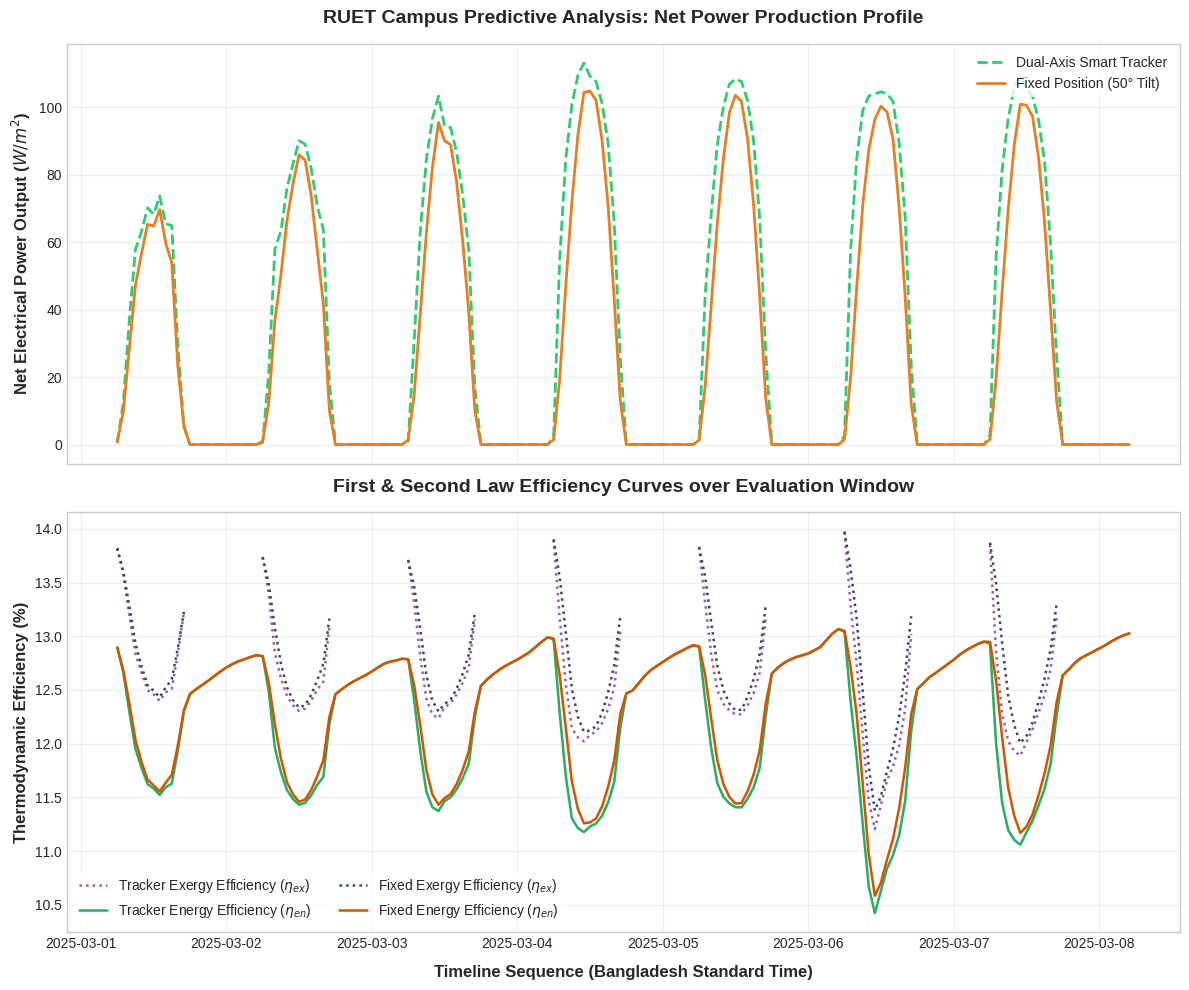

🎉 Graphs generated perfectly and saved as 'RUET_solar_thermodynamic_profiles.png'!


In [6]:
# ------------------------------------------------------------------------------
# PHASE 5: PUBLICATION-GRADE VISUALIZATION ENGINE (FIXED)
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt

# 1. Safe style selection (plt.style.available is a list, no parentheses)
if 'seaborn-v0_8-whitegrid' in plt.style.available:
    plt.style.use('seaborn-v0_8-whitegrid')
else:
    plt.style.use('default')

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Net Power Output Comparison (W/m²)
axes[0].plot(analysis_table.index, analysis_table['Power_Tracker'], label='Dual-Axis Smart Tracker', color='#2ecc71', linewidth=2, linestyle='--')
axes[0].plot(analysis_table.index, analysis_table['Power_Fixed'], label='Fixed Position (50° Tilt)', color='#e67e22', linewidth=2)
axes[0].set_ylabel('Net Electrical Power Output ($W/m^2$)', fontsize=12, fontweight='bold')
axes[0].set_title('RUET Campus Predictive Analysis: Net Power Production Profile', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
axes[0].grid(True, alpha=0.3)

# Plot 2: Thermodynamic Efficiencies (Energy vs Exergy using raw strings r'')
axes[1].plot(analysis_table.index, analysis_table['Eta_Exergy_Tracker'], label=r'Tracker Exergy Efficiency ($\eta_{ex}$)', color='#9b59b6', linewidth=1.8, linestyle=':')
axes[1].plot(analysis_table.index, analysis_table['Eta_Energy_Tracker'], label=r'Tracker Energy Efficiency ($\eta_{en}$)', color='#27ae60', linewidth=1.8)
axes[1].plot(analysis_table.index, analysis_table['Eta_Exergy_Fixed'], label=r'Fixed Exergy Efficiency ($\eta_{ex}$)', color='#34495e', linewidth=1.8, linestyle=':')
axes[1].plot(analysis_table.index, analysis_table['Eta_Energy_Fixed'], label=r'Fixed Energy Efficiency ($\eta_{en}$)', color='#d35400', linewidth=1.8)

axes[1].set_ylabel('Thermodynamic Efficiency (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Timeline Sequence (Bangladesh Standard Time)', fontsize=12, fontweight='bold', labelpad=10)
axes[1].set_title('First & Second Law Efficiency Curves over Evaluation Window', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none', ncol=2)
axes[1].grid(True, alpha=0.3)

# Fine-tune layout geometry
plt.tight_layout()

# Save the publication-grade vector graphic directly to your cloud directory
plt.savefig('RUET_solar_thermodynamic_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print("🎉 Graphs generated perfectly and saved as 'RUET_solar_thermodynamic_profiles.png'!")